# Autoencoder-based anomaly detector

Encoder-decoder autoencoder trained on normal samples, using reconstruction error for anomaly detection.

## Imports

In [1]:
# Matplotlib
import matplotlib.pyplot as plt
# Numpy
import numpy as np
# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import copy


In [2]:
# Use GPU if available, else use CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Data

In [3]:
df = pd.read_csv('./data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Separate features and target
X = df.drop('Class', axis=1).copy()
y = df['Class'].astype(np.float32).values

# Train / validation / test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=SEED, stratify=y_train_full
)

# Feature engineering for skewed columns
for frame in (X_train, X_val, X_test):
    frame['Amount'] = np.log1p(frame['Amount'])
    frame['Time'] = np.log1p(frame['Time'])

# Normalize using training statistics only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

n_train = len(y_train)
n_fraud = int((y_train == 1).sum().item())
n_normal = int((y_train == 0).sum().item())

print(f"Train samples: {n_train}")
print(f"Normal transactions: {n_normal}")
print(f"Fraudulent transactions: {n_fraud}")

Train samples: 170883
Normal transactions: 170588
Fraudulent transactions: 295


## Create DataLoaders

For the autoencoder, the training loader should contain **normal transactions only**.

In [5]:
# Custom Dataset class
class FraudDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Build normal-only training set for anomaly detection
normal_train_mask = (y_train == 0)
X_train_normal = X_train[normal_train_mask]
y_train_normal = y_train[normal_train_mask]

# Create datasets
train_normal_dataset = FraudDataset(X_train_normal, y_train_normal)
val_dataset = FraudDataset(X_val, y_val)
test_dataset = FraudDataset(X_test, y_test)

# DataLoader configuration
BATCH_SIZE = 512
NUM_WORKERS = 0

train_normal_dataloader = DataLoader(
    train_normal_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Normal-only train DataLoader: {len(train_normal_dataloader)} batches")
print(f"Val DataLoader: {len(val_dataloader)} batches")
print(f"Test DataLoader: {len(test_dataloader)} batches")
print(f"Normal-only train samples: {len(train_normal_dataset)}")

Normal-only train DataLoader: 334 batches
Val DataLoader: 112 batches
Test DataLoader: 112 batches
Normal-only train samples: 170588


In [6]:
# Test DataLoader by iterating through a few batches
print("Sample batches from normal-only training data:\n")

for batch_number, (inputs, outputs) in enumerate(train_normal_dataloader):
    print("---")
    print(f"Batch number: {batch_number}")
    print(f"Inputs shape: {inputs.shape}")
    print(f"Outputs shape: {outputs.shape}")

    if batch_number == 2:
        break

Sample batches from normal-only training data:

---
Batch number: 0
Inputs shape: torch.Size([512, 30])
Outputs shape: torch.Size([512])
---
Batch number: 1
Inputs shape: torch.Size([512, 30])
Outputs shape: torch.Size([512])
---
Batch number: 2
Inputs shape: torch.Size([512, 30])
Outputs shape: torch.Size([512])


# Model

In [7]:
class FraudAutoencoder(nn.Module):
    def __init__(self, input_dim=30):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

# Initialize model
model = FraudAutoencoder(input_dim=X_train.shape[1]).to(device)
print(model)

FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=30, bias=True)
  )
)


## Training Setup

In [8]:
# Loss function & optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print("Loss Function: Mean Squared Error")
print("Optimizer: AdamW (lr=1e-3, weight_decay=1e-4)")
print("Scheduler: ReduceLROnPlateau monitoring validation reconstruction loss")

Loss Function: Mean Squared Error
Optimizer: AdamW (lr=1e-3, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau monitoring validation reconstruction loss


# Training Loop

Added:
- train on **normal transactions only**
- validation on full validation set
- early stopping
- learning-rate scheduling

In [9]:
from sklearn.metrics import f1_score, average_precision_score

# To collect reconstruction errors for a given dataloader
def collect_reconstruction_errors(model, dataloader, device):
    model.eval()
    all_errors = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            reconstructions = model(inputs)
            batch_errors = torch.mean((reconstructions - inputs) ** 2, dim=1).cpu().numpy()

            all_errors.extend(batch_errors)
            all_labels.extend(labels.numpy())

    return np.array(all_errors), np.array(all_labels)

In [10]:
# Training function
def trainer(model, train_loader, val_loader, num_epochs=30, patience=5):
    best_state = None
    best_val_loss = float("inf")
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_train_loss = 0.0

        for inputs, _ in train_loader:
            inputs = inputs.to(device)

            optimizer.zero_grad()
            reconstructions = model(inputs)
            loss = criterion(reconstructions, inputs)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for inputs, _ in val_loader:
                inputs = inputs.to(device)
                reconstructions = model(inputs)
                loss = criterion(reconstructions, inputs)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {avg_train_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f}"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses

print("Starting autoencoder training...\n")
train_losses, val_losses = trainer(
    model,
    train_normal_dataloader,
    val_dataloader,
    num_epochs=30,
    patience=5
)
print("\nTraining complete!")

Starting autoencoder training...

Epoch [1/30] | Train Loss: 0.674600 | Val Loss: 0.522606
Epoch [2/30] | Train Loss: 0.400075 | Val Loss: 0.327777
Epoch [3/30] | Train Loss: 0.281043 | Val Loss: 0.237511
Epoch [4/30] | Train Loss: 0.227563 | Val Loss: 0.198779
Epoch [5/30] | Train Loss: 0.201060 | Val Loss: 0.179393
Epoch [6/30] | Train Loss: 0.179775 | Val Loss: 0.155720
Epoch [7/30] | Train Loss: 0.166557 | Val Loss: 0.147174
Epoch [8/30] | Train Loss: 0.158054 | Val Loss: 0.138771
Epoch [9/30] | Train Loss: 0.153641 | Val Loss: 0.133963
Epoch [10/30] | Train Loss: 0.147848 | Val Loss: 0.130042
Epoch [11/30] | Train Loss: 0.144621 | Val Loss: 0.128660
Epoch [12/30] | Train Loss: 0.140837 | Val Loss: 0.122769
Epoch [13/30] | Train Loss: 0.136545 | Val Loss: 0.119513
Epoch [14/30] | Train Loss: 0.134827 | Val Loss: 0.120051
Epoch [15/30] | Train Loss: 0.132543 | Val Loss: 0.114302
Epoch [16/30] | Train Loss: 0.129559 | Val Loss: 0.115823
Epoch [17/30] | Train Loss: 0.127387 | Val Loss

# Evaluation & Testing

We use the **reconstruction error** as the anomaly score.

Higher reconstruction error means the transaction looks less like the normal patterns the
autoencoder learned during training.

We report:
- **Accuracy**
- **Balanced Accuracy**
- **Precision**
- **Recall**
- **F1 Score**
- **ROC-AUC** (using reconstruction error as the score)
- **PR-AUC** (using reconstruction error as the score)

The classification threshold is selected on the **validation set**.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Evaluation function
def evaluate(model, dataloader, device, threshold):
    errors, labels = collect_reconstruction_errors(model, dataloader, device)
    preds = (errors >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, errors),
        "pr_auc": average_precision_score(labels, errors),
        "confusion_matrix": confusion_matrix(labels, preds)
    }

    return metrics

# Threshold search
val_errors, val_labels = collect_reconstruction_errors(model, val_dataloader, device)

threshold_percentiles = [90, 95, 97, 98, 99, 99.5, 99.7, 99.9]
candidate_thresholds = np.percentile(val_errors, threshold_percentiles)

print("=" * 50)
print("VALIDATION THRESHOLD SEARCH (RECONSTRUCTION ERROR)")
print("=" * 50)

best_threshold = candidate_thresholds[0]
best_f1 = -1.0

for percentile, thr in zip(threshold_percentiles, candidate_thresholds):
    metrics = evaluate(model, val_dataloader, device, threshold=thr)
    print(
        f"Percentile: {percentile:>5} | "
        f"Threshold: {thr:.6f} | "
        f"Precision: {metrics['precision']:.4f} | "
        f"Recall: {metrics['recall']:.4f} | "
        f"F1: {metrics['f1']:.4f}"
    )

    if metrics["f1"] > best_f1:
        best_f1 = metrics["f1"]
        best_threshold = thr

print(f"\nBest threshold from validation set: {best_threshold:.6f}")
print(f"Best validation F1: {best_f1:.4f}")

# Final evaluation on test set using best threshold
test_metrics = evaluate(model, test_dataloader, device, threshold=best_threshold)

print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"Threshold:         {best_threshold:.6f}")
print(f"Accuracy:          {test_metrics['accuracy']:.4f}")
print(f"Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"Precision:         {test_metrics['precision']:.4f}")
print(f"Recall:            {test_metrics['recall']:.4f}")
print(f"F1 Score:          {test_metrics['f1']:.4f}")
print(f"ROC-AUC:           {test_metrics['roc_auc']:.4f}")
print(f"PR-AUC:            {test_metrics['pr_auc']:.4f}")

tn, fp, fn, tp = test_metrics["confusion_matrix"].ravel()
print("\nConfusion Matrix:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

VALIDATION THRESHOLD SEARCH (RECONSTRUCTION ERROR)
Percentile:    90 | Threshold: 0.134815 | Precision: 0.0149 | Recall: 0.8586 | F1: 0.0293
Percentile:    95 | Threshold: 0.222680 | Precision: 0.0284 | Recall: 0.8182 | F1: 0.0550
Percentile:    97 | Threshold: 0.316320 | Precision: 0.0468 | Recall: 0.8081 | F1: 0.0885
Percentile:    98 | Threshold: 0.419553 | Precision: 0.0684 | Recall: 0.7879 | F1: 0.1259
Percentile:    99 | Threshold: 0.635292 | Precision: 0.1333 | Recall: 0.7677 | F1: 0.2272
Percentile:  99.5 | Threshold: 0.922200 | Precision: 0.2596 | Recall: 0.7475 | F1: 0.3854
Percentile:  99.7 | Threshold: 1.269994 | Precision: 0.4327 | Recall: 0.7475 | F1: 0.5481
Percentile:  99.9 | Threshold: 5.970627 | Precision: 0.7895 | Recall: 0.4545 | F1: 0.5769

Best threshold from validation set: 5.970627
Best validation F1: 0.5769

TEST SET RESULTS
Threshold:         5.970627
Accuracy:          0.9990
Balanced Accuracy: 0.7856
Precision:         0.8116
Recall:            0.5714
F1 Sco

# Visualization

Loss graph and F1-matrix

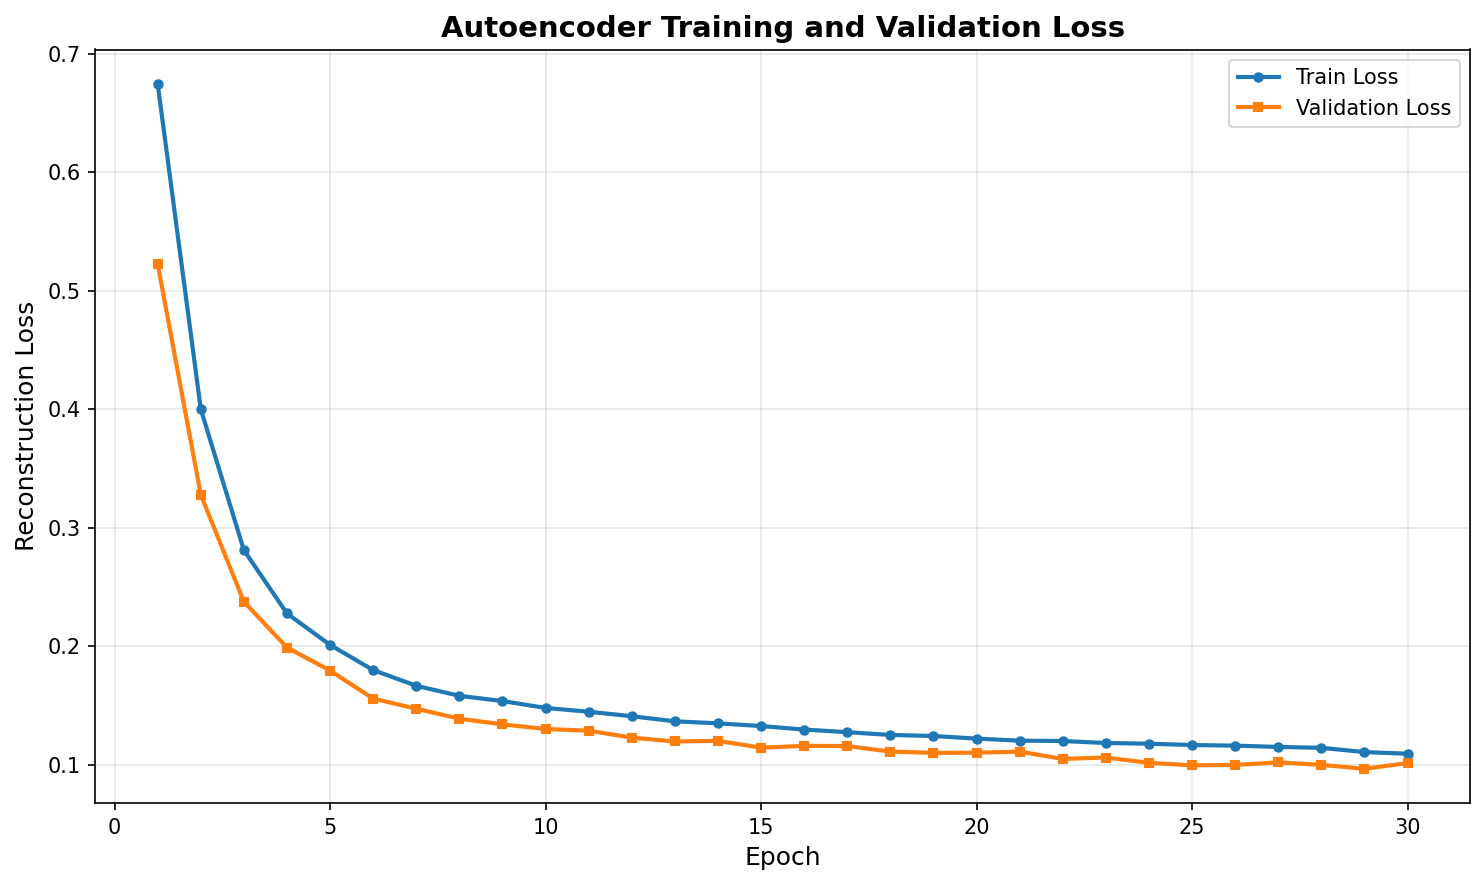

In [ ]:
import matplotlib.pyplot as plt

# OPTIONAL: compute test reconstruction loss if not already done
def compute_avg_reconstruction_loss(model, dataloader, device, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.to(device)
            recon = model(inputs)
            loss = criterion(recon, inputs)
            total_loss += loss.item()

    return total_loss / len(dataloader)

test_loss = compute_avg_reconstruction_loss(model, test_dataloader, device, criterion)

# Create figure with custom width ratio
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [2.5, 1]},
    dpi=150
)

# ===== LEFT: LOSS GRAPH =====
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, label='Train Loss', linewidth=2, marker='o', markersize=4)
ax1.plot(epochs, val_losses, label='Validation Loss', linewidth=2, marker='s', markersize=4)
ax1.axhline(y=test_loss, linestyle='--', label=f'Test Loss: {test_loss:.4f}', linewidth=2)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Reconstruction Loss', fontsize=12)
ax1.set_title('Autoencoder Training, Validation & Test Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ===== RIGHT: METRICS =====
ax2.axis('off')

# Extract confusion matrix values
tn, fp, fn, tp = test_metrics["confusion_matrix"].ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)

metrics_text = f"""AUTOENCODER RESULTS

Threshold: {best_threshold:.6f}

Accuracy:  {test_metrics['accuracy']:.4f}
Balanced:  {test_metrics['balanced_accuracy']:.4f}
Precision: {test_metrics['precision']:.4f}
Recall:    {test_metrics['recall']:.4f}
F1 Score:  {test_metrics['f1']:.4f}
ROC-AUC:   {test_metrics['roc_auc']:.4f}
PR-AUC:    {test_metrics['pr_auc']:.4f}

CONFUSION MATRIX
TP: {tp:>6}    FP: {fp:>6}
FN: {fn:>6}    TN: {tn:>6}
"""

ax2.text(
    0.05, 0.5, metrics_text,
    fontsize=11,
    family='monospace',
    verticalalignment='center',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7)
)

plt.tight_layout()
plt.show()

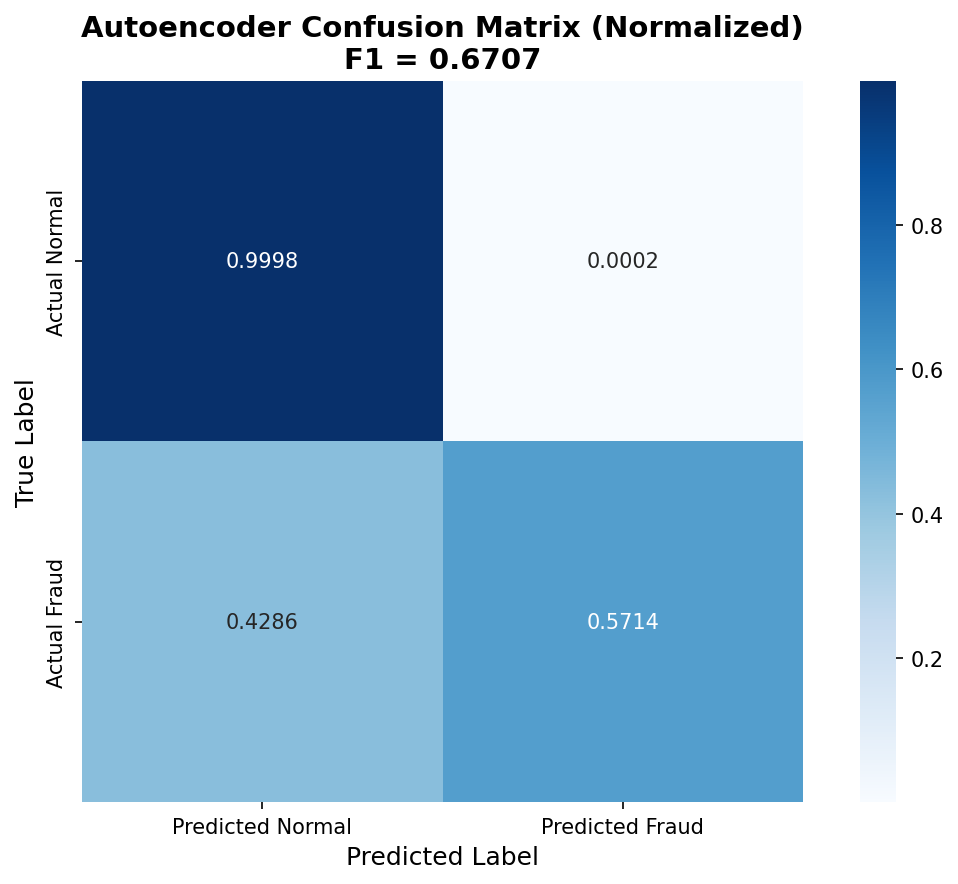

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Extract confusion matrix
cm = test_metrics["confusion_matrix"]

# Normalize by row (actual class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6), dpi=150)

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Fraud'],
    yticklabels=['Actual Normal', 'Actual Fraud'],
    cbar=True,
    square=True
)

plt.title(
    f'Autoencoder Confusion Matrix (Normalized)\nF1 = {test_metrics["f1"]:.4f}',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()